**Table of contents**
1. [Set up and config](#1)
2. [Xử lý dữ liệu và EDA](#2)
3. [Mô hình và huấn luyện mô hình](#3)
4. [Đánh giá mô hình](#4)

# 1. Set up and config <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from dataclasses import dataclass
import scipy
import sklearn
import random

In [2]:
from preprocessing import prepare_classification_data
from eda import (
  summarize_dataset,
  summarize_numeric_statistics,
  plot_class_distribution,
  plot_correlation_heatmap,
  plot_top_feature_distributions,
  )
from utils import plot_learning_curve, plot_loss_curve, plot_2d_decision_boundary
from eval import (
  mcnemar_paired,
  reliability_diagram_multiclass
)
from models import (
  LogisticRegression as LR,
  SoftmaxRegression as SR,
  ProbitRegression as PR,
  LDA,
  QDA,
  GaussianNaiveBayes as GNB,
  KernelLogisticRegression as KLR
)

## Configuaration

In [ ]:
# reproducibility
SEED = 42

# hyperparameters
LEARNING_RATE = .01
MAX_ITER = 10_000
REG = 1e-4
EPS = 1e-4
EPOCHS = 100
BATCH_SIZE = 100

# statistical significance level
ALPHA = .05

# data path
DATA_PATH = '../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx'

In [4]:
def set_seed(seed: int) -> None:
  random.seed(seed)
  np.random.default_rng(seed)

set_seed(SEED)

# 2. Xử lý dữ liệu và EDA <a id='2'></a>
- Không validation:
$\text{Train} : \text{Test} = 80\% : 20\%$
- Có validation:
$\text{Train} : \text{Val} : \text{Test} = 70\% : 10\% : 20\%$

## 2.1 Xử lý dữ liệu

In [5]:
prepared = prepare_classification_data(
  file_path=DATA_PATH,
  target_col='Class',
  test_size=0.2,
  val_size=0.1,
  random_state=SEED,
)

df = prepared.df
X = prepared.X
y = prepared.y

X_train = prepared.X_train
X_val = prepared.X_val
X_test = prepared.X_test

X_train_scaled = prepared.X_train_scaled
X_val_scaled = prepared.X_val_scaled
X_test_scaled = prepared.X_test_scaled

y_train = prepared.y_train
y_val = prepared.y_val
y_test = prepared.y_test

target_le = prepared.target_encoder

# Keep train+val aliases for later experiments when needed.
X_train_val = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = np.concatenate([y_train, y_val])

Loaded ../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx -> shape (13611, 17)
Split sizes -> train: 9527, val: 1361, test: 2723


In [6]:
print(f"X_train_scaled.shape: {X_train_scaled.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test_scaled.shape: {X_test_scaled.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train_scaled.shape: (9527, 16)
y_train.shape: (9527,)
X_test_scaled.shape: (2723, 16)
y_test.shape: (2723,)


In [7]:
print(f"X_train_val.shape: {X_train_val.shape}")
print(f"y_train_val.shape: {y_train_val.shape}")
print(f"X_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")

X_train_val.shape: (10888, 16)
y_train_val.shape: (10888,)
X_val.shape: (1361, 16)
y_val.shape: (1361,)


In [8]:
C = np.unique(y_train).shape[0]
print(f"Target classes identified: {target_le.classes_}")
print(f"Number of classes (C): {C}")

Target classes identified: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Number of classes (C): 7


## 2.2 EDA

In [9]:
missing_summary = summarize_dataset(df, target_col='Class')

Shape: (13611, 17)

Dtypes:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Missing values: none

Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [10]:
feature_stats = summarize_numeric_statistics(X_train)

print('Descriptive statistics for numeric training features:')
feature_stats

Descriptive statistics for numeric training features:


,count,mean,std,min,q1,median,q3,max,iqr,missing_count,missing_rate
ConvexArea,9527.0,53811.5595,29911.7025,20684.0000,36683.5000,45244.0000,62433.5000,251082.0000,25750.0000,0,0.0
Area,9527.0,53090.9794,29464.6579,20420.0000,36299.5000,44710.0000,61458.5000,248424.0000,25159.0000,0,0.0
Perimeter,9527.0,855.4060,214.7239,524.7360,703.3640,795.3500,977.1465,1895.9400,273.7825,0,0.0
MajorAxisLength,9527.0,320.1449,85.8462,183.6012,253.2807,297.1470,376.0820,726.3735,122.8013,0,0.0
EquivDiameter,9527.0,253.1285,59.3623,161.2438,214.9836,238.5928,279.7345,562.4084,64.7509,0,0.0
MinorAxisLength,9527.0,202.3719,45.1374,122.5127,175.8721,192.4798,217.0575,460.1985,41.1853,0,0.0
AspectRation,9527.0,1.5824,0.2462,1.0364,1.4321,1.5503,1.7054,2.4303,0.2732,0,0.0
ShapeFactor3,9527.0,0.6439,0.0989,0.4103,0.5819,0.6422,0.6960,0.9636,0.1141,0,0.0
Eccentricity,9527.0,0.7507,0.0919,0.2628,0.7158,0.7641,0.8100,0.9114,0.0942,0,0.0
Compactness,9527.0,0.8000,0.0617,0.6406,0.7628,0.8014,0.8343,0.9816,0.0715,0,0.0


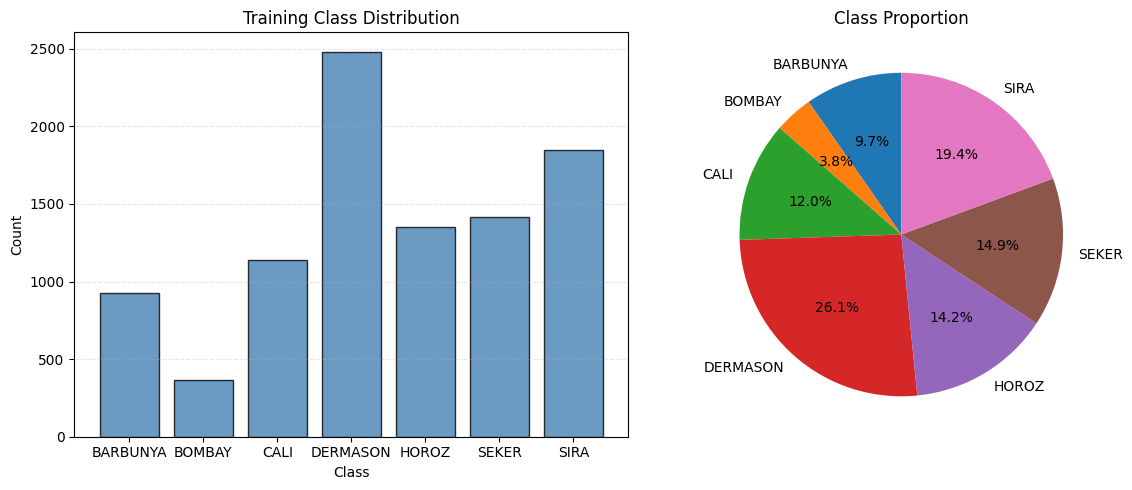

In [11]:
plot_class_distribution(
  y_train,
  class_names=target_le.classes_,
  title='Training Class Distribution',
)

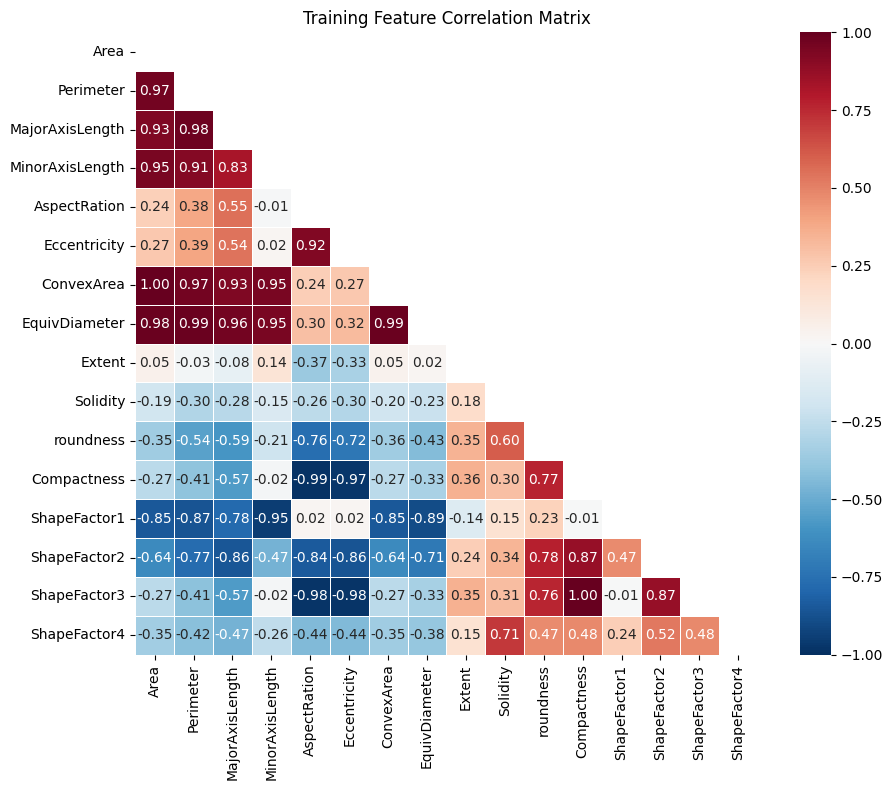

In [12]:
plot_correlation_heatmap(
  X_train,
  title='Training Feature Correlation Matrix',
)

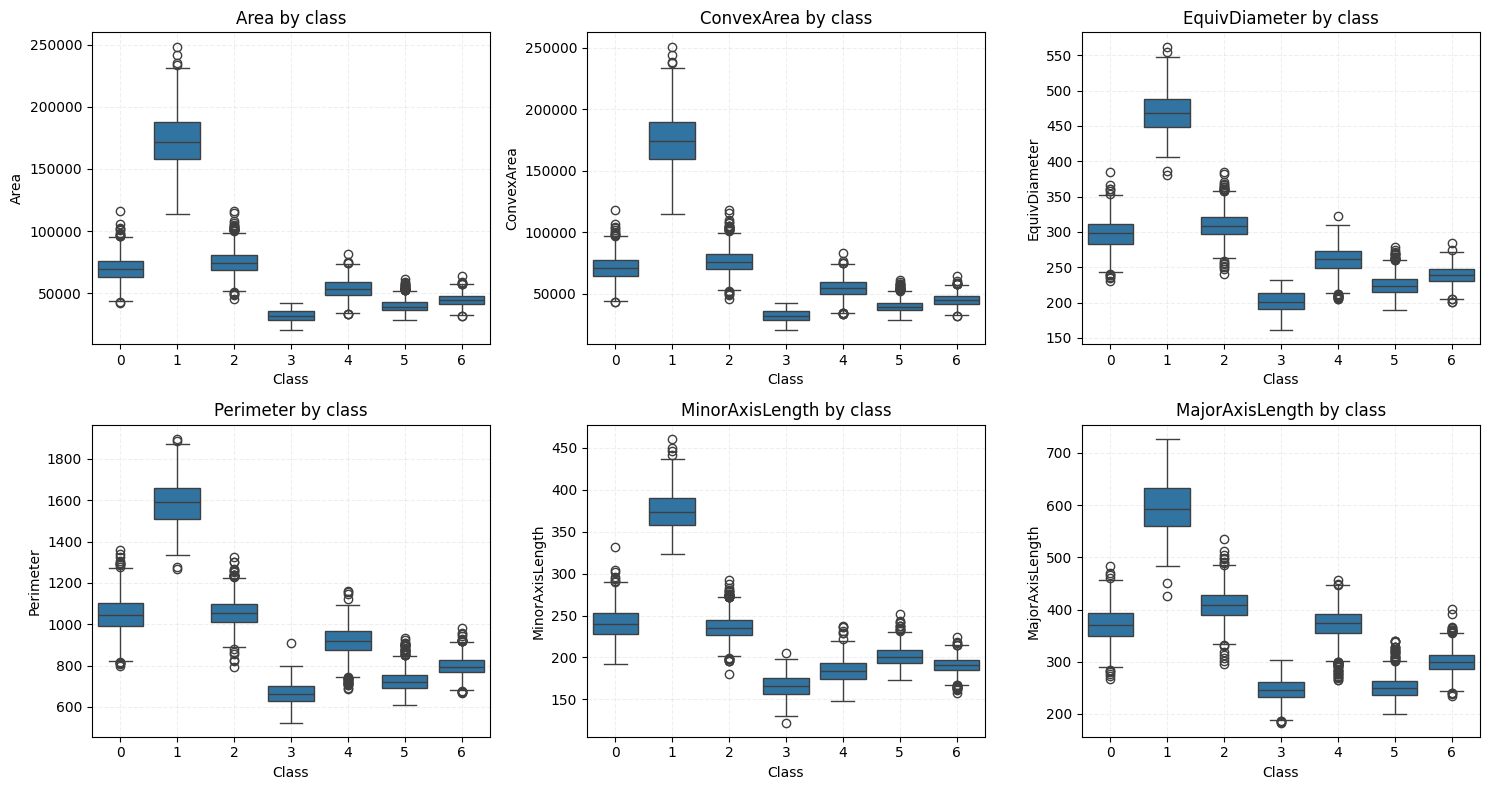

In [13]:
plot_top_feature_distributions(
  X_train,
  y_train,
  top_n=6,
)

# 3. Mô hình và huấn luyện mô hình <a id='3'></a>

In [14]:
models = {}

## 3.1 Logistic Regression (nhị phân và đa lớp)

### 3.1.1 Logistic Regression

In [15]:
from models import LogisticRegression

# Create a binary classification sub-problem for algorithms that strictly require it
# We select classes 0 and 1 for simplicity. Features 0 and 1 are kept to allow 2D plot later
mask_train = (y_train == 0) | (y_train == 1)
mask_test = (y_test == 0) | (y_test == 1)

X_train_bin = X_train_scaled[mask_train][:, :2]  # First two features for 2D plotting
y_train_bin = y_train[mask_train]
X_test_bin = X_test_scaled[mask_test][:, :2]
y_test_bin = y_test[mask_test]

logreg = LogisticRegression(learning_rate=LEARNING_RATE, eps=EPS)
logreg.fit(X=X_train_bin, y=y_train_bin)
models['Logistic Regression (Binary)'] = logreg
logreg_preds = logreg.predict(X=X_test_bin)
logreg_eval = logreg.evaluate(y_pred=logreg_preds, y_true=y_test_bin)
print("Logistic Regression Binary Evaluation:", logreg_eval)


Iteration 0: Loss 0.6931
Iteration 100: Loss 0.5727
Iteration 200: Loss 0.4947
Iteration 300: Loss 0.4329
Iteration 400: Loss 0.3833
Iteration 500: Loss 0.3429
Iteration 600: Loss 0.3097
Iteration 700: Loss 0.2820
Iteration 800: Loss 0.2587
Iteration 900: Loss 0.2388
Iteration 1000: Loss 0.2217
Iteration 1100: Loss 0.2068
Iteration 1200: Loss 0.1938
Iteration 1300: Loss 0.1823
Iteration 1400: Loss 0.1721
Iteration 1500: Loss 0.1630
Iteration 1600: Loss 0.1549
Iteration 1700: Loss 0.1475
Iteration 1800: Loss 0.1408
Iteration 1900: Loss 0.1347
Iteration 2000: Loss 0.1291
Iteration 2100: Loss 0.1240
Iteration 2200: Loss 0.1193
Iteration 2300: Loss 0.1150
Iteration 2400: Loss 0.1110
Iteration 2500: Loss 0.1072
Iteration 2600: Loss 0.1037
Iteration 2700: Loss 0.1005
Iteration 2800: Loss 0.0974
Iteration 2900: Loss 0.0946
Iteration 3000: Loss 0.0919
Iteration 3100: Loss 0.0894
Iteration 3200: Loss 0.0870
Iteration 3300: Loss 0.0847
Iteration 3400: Loss 0.0826
Iteration 3500: Loss 0.0806
Iter

### 3.1.2 Các chiến thuật khi phân lớp đa lớp
- One-vs-Rest (OvR)
- One-vs-One (OvO)
- Softmax Regression (Multinomial Logistic Regression)

In [16]:
from eval import evaluate_multiclass_strategy


In [17]:
from utils import ovr_predict_with_logistic

ovr_preds, ovr_models = ovr_predict_with_logistic(
  X_train_scaled,
  y_train,
  X_test_scaled,
  LEARNING_RATE, EPS, MAX_ITER
)
ovr_metrics = evaluate_multiclass_strategy(y_test, ovr_preds, 'One-vs-Rest (OvR)')


Iteration 0: Loss 0.6931
Iteration 100: Loss 0.5357
Iteration 200: Loss 0.4418
Iteration 300: Loss 0.3792
Iteration 400: Loss 0.3352
Iteration 500: Loss 0.3029
Iteration 600: Loss 0.2784
Iteration 700: Loss 0.2591
Iteration 800: Loss 0.2436
Iteration 900: Loss 0.2308
Iteration 1000: Loss 0.2200
Iteration 1100: Loss 0.2109
Iteration 1200: Loss 0.2030
Iteration 1300: Loss 0.1961
Iteration 1400: Loss 0.1900
Iteration 1500: Loss 0.1846
Iteration 1600: Loss 0.1797
Iteration 1700: Loss 0.1753
Iteration 1800: Loss 0.1713
Iteration 1900: Loss 0.1677
Iteration 2000: Loss 0.1644
Iteration 2100: Loss 0.1613
Iteration 2200: Loss 0.1585
Iteration 2300: Loss 0.1558
Iteration 2400: Loss 0.1534
Iteration 2500: Loss 0.1511
Iteration 2600: Loss 0.1490
Iteration 2700: Loss 0.1470
Iteration 2800: Loss 0.1451
Iteration 2900: Loss 0.1433
Iteration 3000: Loss 0.1416
Iteration 3100: Loss 0.1400
Iteration 3200: Loss 0.1385
Iteration 3300: Loss 0.1370
Iteration 3400: Loss 0.1356
Iteration 3500: Loss 0.1343
Iter

In [18]:
from utils import ovo_predict_with_logistic

ovo_preds, ovo_models = ovo_predict_with_logistic(
  X_train_scaled,
  y_train,
  X_test_scaled,
  LEARNING_RATE, EPS, MAX_ITER
)
ovo_metrics = evaluate_multiclass_strategy(y_test, ovo_preds, 'One-vs-One (OvO)')


Iteration 0: Loss 0.6931
Iteration 100: Loss 0.3682
Iteration 200: Loss 0.2595
Iteration 300: Loss 0.2043
Iteration 400: Loss 0.1705
Iteration 500: Loss 0.1474
Iteration 600: Loss 0.1304
Iteration 700: Loss 0.1174
Iteration 800: Loss 0.1070
Iteration 900: Loss 0.0985
Iteration 1000: Loss 0.0915
Iteration 1100: Loss 0.0854
Iteration 1200: Loss 0.0802
Iteration 1300: Loss 0.0757
Iteration 1400: Loss 0.0717
Iteration 1500: Loss 0.0682
Iteration 1600: Loss 0.0650
Iteration 1700: Loss 0.0622
Iteration 1800: Loss 0.0596
Iteration 1900: Loss 0.0572
Iteration 2000: Loss 0.0551
Iteration 2100: Loss 0.0531
Iteration 2200: Loss 0.0513
Iteration 2300: Loss 0.0496
Iteration 2400: Loss 0.0480
Iteration 2500: Loss 0.0465
Iteration 2600: Loss 0.0452
Iteration 2700: Loss 0.0439
Iteration 2800: Loss 0.0427
Iteration 2900: Loss 0.0415
Iteration 3000: Loss 0.0405
Iteration 3100: Loss 0.0395
Iteration 3200: Loss 0.0385
Iteration 3300: Loss 0.0376
Iteration 3400: Loss 0.0367
Iteration 3500: Loss 0.0359
Iter

In [19]:
softmax_model = SR(learning_rate=LEARNING_RATE, eps=EPS, max_iter=MAX_ITER)
softmax_model.fit(X_train_scaled, y_train)

softmax_preds = softmax_model.predict(X_test_scaled)
softmax_metrics = evaluate_multiclass_strategy(
  y_test,
  softmax_preds,
  'Softmax Regression (Multinomial)',
  )

if 'models' not in globals():
  models = {}
models['Softmax Regression'] = softmax_model

Iteration 0: Loss 1.9459
Iteration 100: Loss 1.2207
Iteration 200: Loss 0.9937
Iteration 300: Loss 0.8740
Iteration 400: Loss 0.7943
Iteration 500: Loss 0.7349
Iteration 600: Loss 0.6880
Iteration 700: Loss 0.6496
Iteration 800: Loss 0.6173
Iteration 900: Loss 0.5897
Iteration 1000: Loss 0.5657
Iteration 1100: Loss 0.5447
Iteration 1200: Loss 0.5262
Iteration 1300: Loss 0.5096
Iteration 1400: Loss 0.4948
Iteration 1500: Loss 0.4814
Iteration 1600: Loss 0.4693
Iteration 1700: Loss 0.4582
Iteration 1800: Loss 0.4481
Iteration 1900: Loss 0.4388
Iteration 2000: Loss 0.4302
Iteration 2100: Loss 0.4222
Iteration 2200: Loss 0.4149
Iteration 2300: Loss 0.4080
Iteration 2400: Loss 0.4016
Iteration 2500: Loss 0.3956
Iteration 2600: Loss 0.3900
Iteration 2700: Loss 0.3847
Iteration 2800: Loss 0.3798
Iteration 2900: Loss 0.3751
Iteration 3000: Loss 0.3707
Iteration 3100: Loss 0.3665
Iteration 3200: Loss 0.3626
Iteration 3300: Loss 0.3588
Iteration 3400: Loss 0.3553
Iteration 3500: Loss 0.3519
Iter

In [20]:
strategy_results_df = pd.DataFrame([
  ovr_metrics,
  ovo_metrics,
  softmax_metrics,
]).set_index('strategy')

print('Comparison of multiclass classification strategies:')
strategy_results_df.sort_values('accuracy', ascending=False)

Comparison of multiclass classification strategies:


,accuracy,precision,recall,f1-score
strategy,,,,
One-vs-One (OvO),0.918472,0.918742,0.918472,0.918372
Softmax Regression (Multinomial),0.915167,0.916044,0.915167,0.915315
One-vs-Rest (OvR),0.893867,0.893853,0.893867,0.893523


### 3.1.x Laplace Approximation (Bayesian Logistic Regression)

In [21]:
from models import LogisticRegression

blr = LogisticRegression(learning_rate=LEARNING_RATE, eps=EPS)
blr.fit(X=X_train_bin, y=y_train_bin, solver='laplace_approximation')

models['Bayesian Logistic Regression (Laplace)'] = blr

blr_preds = blr.predict(X=X_test_bin)
blr_eval = blr.evaluate(y_pred=blr_preds, y_true=y_test_bin)
blr_acc = blr_eval['accuracy']
print(f'Bayesian Logistic Regression (Laplace Approximation) accuracy: {blr_acc:.2f}')


Iteration 0: MAP objective 0.6941
Converged at iteration 9: step norm 6.221906e-07 < eps 1.000000e-04
Bayesian Logistic Regression (Laplace Approximation) accuracy: 1.00


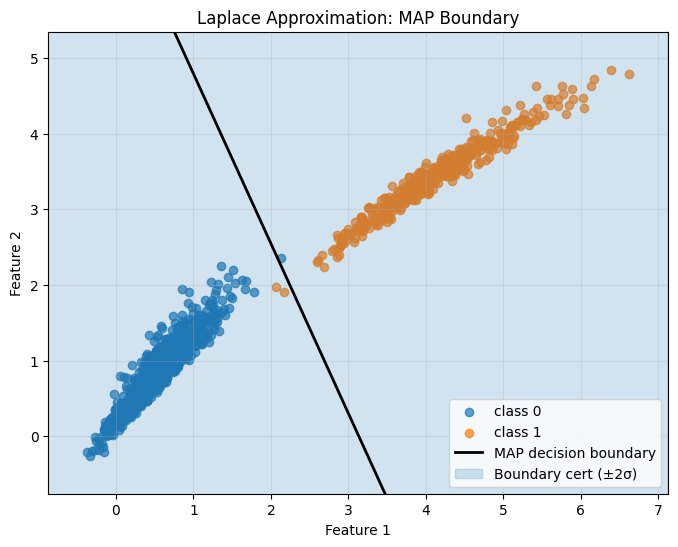

In [22]:
# 1) MAP parameters from the fitted Bayesian logistic regression
theta_map = blr.theta.copy()                    
X_aug = blr._augment(X_train_bin)            
y_binary = (y_train_bin == blr.classes_[1]).astype(float)

logits_map = X_aug @ theta_map
probs_map = 1.0 / (1.0 + np.exp(-np.clip(logits_map, -500, 500)))
W_diag = probs_map * (1.0 - probs_map)

n_samples = X_aug.shape[0]
prior_mask = blr._prior_mask(X_aug.shape[1])
reg = blr.prior_precision / n_samples

H_map = (X_aug.T * W_diag) @ X_aug / n_samples
H_map += reg * np.diag(prior_mask)
H_map += 1e-8 * np.eye(X_aug.shape[1])

posterior_cov = np.linalg.pinv(H_map)
posterior_cov = 0.5 * (posterior_cov + posterior_cov.T)
posterior_mean = theta_map

w1, w2, b = posterior_mean
if np.isclose(w2, 0.0):
    print("w2 near zero, skipping 2D plot")
else:
    x_grid = np.linspace(X_train_bin[:, 0].min() - 0.5, X_train_bin[:, 0].max() + 0.5, 400)
    y_boundary_mean = -(b + w1 * x_grid) / w2

    grads = np.column_stack([
        -x_grid / w2,
        (b + w1 * x_grid) / (w2 ** 2),
        -np.ones_like(x_grid) / w2,
    ])
    boundary_var = np.einsum('bi,ij,bj->b', grads, posterior_cov, grads)
    boundary_var = np.maximum(boundary_var, 0.0)
    boundary_std = np.sqrt(boundary_var)

    y_upper = y_boundary_mean + 2.0 * boundary_std
    y_lower = y_boundary_mean - 2.0 * boundary_std

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_train_bin[y_train_bin == blr.classes_[0], 0],
        X_train_bin[y_train_bin == blr.classes_[0], 1],
        label=f'class {blr.classes_[0]}', alpha=0.7,
    )
    plt.scatter(
        X_train_bin[y_train_bin == blr.classes_[1], 0],
        X_train_bin[y_train_bin == blr.classes_[1], 1],
        label=f'class {blr.classes_[1]}', alpha=0.7,
    )
    plt.plot(x_grid, y_boundary_mean, color='black', linewidth=2, label='MAP decision boundary')
    plt.fill_between(x_grid, y_lower, y_upper, color='tab:blue', alpha=0.2, label='Boundary cert (±2σ)')
    plt.xlim(x_grid.min(), x_grid.max())
    plt.ylim(X_train_bin[:, 1].min() - 0.5, X_train_bin[:, 1].max() + 0.5)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Laplace Approximation: MAP Boundary')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 3.2 Linear Discriminant Analysis - LDA và QDA

### 3.2.1 LDA và QDA

#### LDA

In [23]:
from models import LDA

lda = LDA(reg=REG)
lda.fit(X=X_train_scaled, y=y_train)

models['LDA'] = lda

lda_preds = lda.predict(X=X_test_scaled)

lda_eval = lda.evaluate(y_pred=lda_preds, y_true=y_test)
lda_acc = lda_eval['accuracy']
print(f'LDA accuracy: {lda_acc:.4f}')

LDA accuracy: 0.9019


#### QDA

In [24]:
from models import QDA

qda = QDA(reg=REG)
qda.fit(X=X_train_scaled, y=y_train)

models['QDA'] = qda

qda_preds = qda.predict(X=X_test_scaled)
qda_eval = qda.evaluate(y_pred=qda_preds, y_true=y_test)
qda_acc = qda_eval['accuracy']
print(f'QDA accuracy: {qda_acc:.4f}')

QDA accuracy: 0.9071


### 3.2.2 Fisher ratio feature ranking

For each feature $x_j$, we treat the projection direction as selecting that single coordinate, so the Fisher criterion becomes

$$
J(w_j) = J_j = \frac{\sum_{c=1}^{C} n_c (\mu_{c,j} - \mu_j)^2}{\sum_{c=1}^{C} n_c \, \sigma_{c,j}^2}
$$

where $n_c$ is the number of training samples in class $c$, $\mu_{c,j}$ and $\sigma_{c,j}^2$ are the class-wise mean and variance of feature $j$, and $\mu_j$ is the global mean of feature $j$. A larger $J_j$ means the feature separates classes better relative to its within-class spread.

In [25]:
# Fisher ratio for each feature (multiclass version)
# J_j = sum_c n_c (mu_cj - mu_j)^2 / sum_c n_c sigma_cj^2

feature_names = list(X_train.columns)

classes, counts = np.unique(y_train, return_counts=True)
overall_mean = X_train_scaled.mean(axis=0)
fisher_scores = []

for j in range(X_train_scaled.shape[1]):
  between_class = 0.0
  within_class = 0.0

  for cls, n_c in zip(classes, counts):
    x_c = X_train_scaled[y_train == cls, j]
    mu_c = x_c.mean()
    var_c = x_c.var(ddof=1)

    between_class += n_c * (mu_c - overall_mean[j]) ** 2
    within_class += n_c * var_c

  fisher_scores.append(between_class / (within_class + 1e-12))

fisher_df = pd.DataFrame({
  'feature': feature_names,
  'fisher_ratio': fisher_scores,
}).sort_values('fisher_ratio', ascending=False).reset_index(drop=True)

print('Fisher ratio ranking (higher is better):')
fisher_df


Fisher ratio ranking (higher is better):


,feature,fisher_ratio
0,Area,13.038658
1,ConvexArea,13.023622
2,EquivDiameter,11.314876
3,Perimeter,10.791494
4,MinorAxisLength,10.005911
5,MajorAxisLength,9.528009
6,ShapeFactor1,5.375710
7,ShapeFactor2,5.322083
8,AspectRation,4.461345
9,Compactness,4.374068


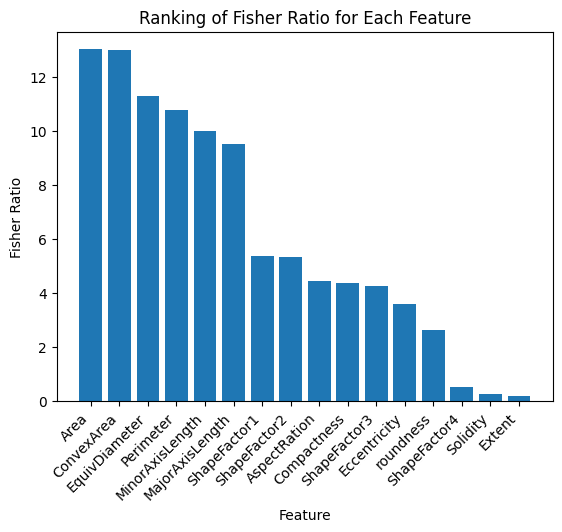

In [26]:
plt.bar(fisher_df['feature'], fisher_df['fisher_ratio'])
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fisher Ratio')
plt.title('Ranking of Fisher Ratio for Each Feature')

plt.show()

### 3.2.3 Vẽ quy chiếu LDA xuống 2D và biểu diễn đường quyết định

LDA 2D projection captures about 0.7599 of the discriminative eigenvalue mass.


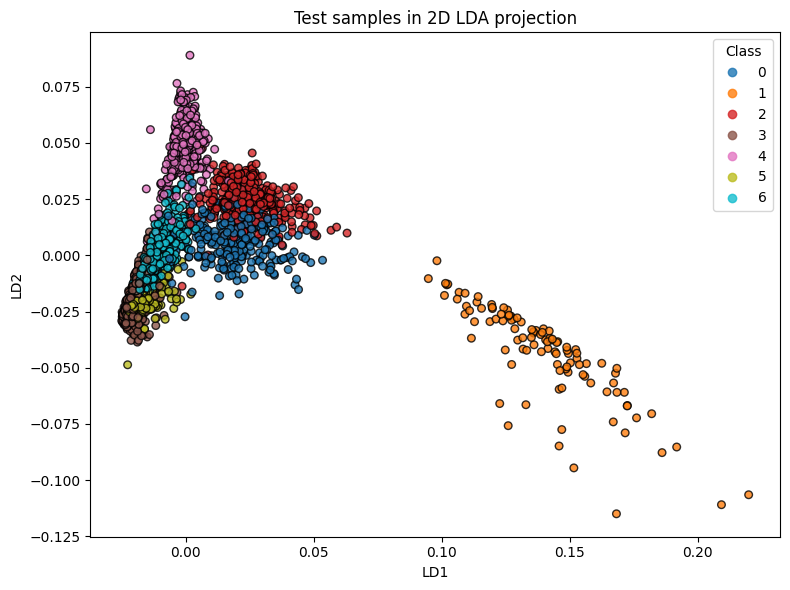

In [27]:
# Project the data to 2D using the LDA model projection methods

lda_projection = LDA(reg=REG)
X_train_lda_2d = lda_projection.fit_transform(X_train_scaled, y_train, n_components=2)
X_test_lda_2d = lda_projection.transform(X_test_scaled, n_components=2)
explained_ratio = lda_projection.explained_discriminative_ratio(n_components=2)
print(f'LDA 2D projection captures about {explained_ratio.sum():.4f} of the discriminative eigenvalue mass.')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  alpha=0.8,
  edgecolor='k',
  s=30,
)
plt.title('Test samples in 2D LDA projection')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(*scatter.legend_elements(), title='Class', loc='best')
plt.tight_layout()
plt.show()

LDA accuracy on 2D projected space: 0.7400


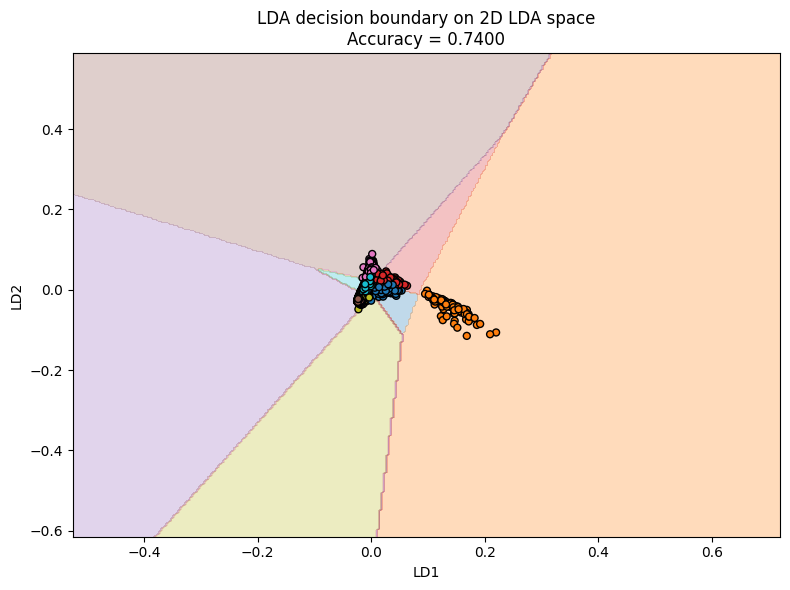

In [28]:
# Fit LDA on the 2D projected space and draw its decision boundary

lda_2d = LDA(reg=REG)
lda_2d.fit(X_train_lda_2d, y_train)
lda_2d_preds_2d = lda_2d.predict(X_test_lda_2d)
lda_eval_2d = lda_2d.evaluate(lda_2d_preds_2d, y_test)
lda_acc_2d = lda_eval_2d['accuracy']
print(f'LDA accuracy on 2D projected space: {lda_acc_2d:.4f}')

all_points = np.vstack([X_train_lda_2d, X_test_lda_2d])
x_min, x_max = all_points[:, 0].min() - 0.5, all_points[:, 0].max() + 0.5
y_min, y_max = all_points[:, 1].min() - 0.5, all_points[:, 1].max() + 0.5
xx, yy = np.meshgrid(
  np.linspace(x_min, x_max, 300),
  np.linspace(y_min, y_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
lda_grid = lda_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, lda_grid, alpha=0.28, cmap='tab10')
plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  edgecolor='k',
  s=25,
)
plt.title(f'LDA decision boundary on 2D LDA space\nAccuracy = {lda_acc_2d:.4f}')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.tight_layout()
plt.show()

### 3.2.4 When LDA is better than QDA, and vice versa

**When LDA is usually better**

- LDA assumes all classes share one covariance matrix, so it estimates far fewer parameters than QDA. This usually makes LDA more stable when the dataset is not very large or the feature space is fairly high-dimensional.
- If the classes mainly differ in their means, while their spread and orientation are similar, the linear boundary from LDA is often sufficient and generalizes better.
- LDA is also less likely to overfit when some classes do not have many training samples.

**When QDA is usually better**

- QDA allows each class to have its own covariance matrix, so it is more appropriate when classes have clearly different spreads, shapes, or orientations.
- If the class boundary is nonlinear, QDA can model it better because its decision surface is quadratic.
- When each class has enough data to estimate its covariance reliably, QDA can exploit that extra flexibility and outperform LDA.

**How to read the plots in this notebook**

- The 2D LDA projection keeps the two most discriminative directions, so it gives the clearest visual view of class separation.
- If the LDA boundary already follows the visible class regions well, then the shared-covariance assumption is likely reasonable.
- If the QDA boundary fits the visible clusters better, especially in curved or uneven-density regions, then class-specific covariance is likely important and QDA is the better model.
- If QDA produces a more complicated boundary without a meaningful gain in accuracy, then its extra flexibility is probably unnecessary and LDA is the safer choice.



### 3.2.5 Gaussian Naive Bayes (giả thiết độc lập) với LDA

In [29]:
from models import GaussianNaiveBayes

gnb = GaussianNaiveBayes(reg=REG)
gnb.fit(X=X_train_scaled, y=y_train)
gnb_preds = gnb.predict(X=X_test_scaled)
gnb_eval = gnb.evaluate(gnb_preds, y_test)
gnb_acc = gnb_eval['accuracy']
print(f'Gaussian Naive Bayes accuracy: {gnb_acc:.4f}')

Gaussian Naive Bayes accuracy: 0.8990


## 3.3 Perceptron và Logistic Regression có Regularization

In [30]:
from models.perceptron import Perceptron
import pandas as pd

perceptron_clf = Perceptron(learning_rate=0.1, max_iter=2000)
perceptron_clf.fit(X_train_bin, y_train_bin)

from eval import classification_report
print("Perceptron Report on Linearly Separable Binary Class:")
print(classification_report(perceptron_clf.predict(X_test_bin), y_test_bin))


Converged at epoch 4
Perceptron Report on Linearly Separable Binary Class:
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0}


## 3.4 Probit

In [31]:
from models import ProbitRegression, KernelLogisticRegression

probit_model = ProbitRegression(learning_rate=0.01, max_iter=5000)
probit_model.fit(X_train_bin, y_train_bin)

models['Probit Regression'] = probit_model
y_test_pred_probit = probit_model.predict(X_test_bin)
print(f"Probit Regression Accuracy: {np.mean(y_test_pred_probit == y_test_bin):.4f}")


Iteration 0: Loss 0.6931
Iteration 100: Loss 0.4558
Iteration 200: Loss 0.3318
Iteration 300: Loss 0.2547
Iteration 400: Loss 0.2037
Iteration 500: Loss 0.1681
Iteration 600: Loss 0.1423
Iteration 700: Loss 0.1228
Iteration 800: Loss 0.1078
Iteration 900: Loss 0.0959
Iteration 1000: Loss 0.0863
Iteration 1100: Loss 0.0783
Iteration 1200: Loss 0.0717
Iteration 1300: Loss 0.0661
Iteration 1400: Loss 0.0613
Iteration 1500: Loss 0.0572
Iteration 1600: Loss 0.0535
Iteration 1700: Loss 0.0504
Iteration 1800: Loss 0.0475
Iteration 1900: Loss 0.0450
Iteration 2000: Loss 0.0428
Iteration 2100: Loss 0.0407
Iteration 2200: Loss 0.0389
Iteration 2300: Loss 0.0372
Iteration 2400: Loss 0.0357
Iteration 2500: Loss 0.0343
Iteration 2600: Loss 0.0330
Iteration 2700: Loss 0.0318
Iteration 2800: Loss 0.0307
Iteration 2900: Loss 0.0297
Iteration 3000: Loss 0.0288
Iteration 3100: Loss 0.0279
Iteration 3200: Loss 0.0271
Iteration 3300: Loss 0.0263
Iteration 3400: Loss 0.0256
Iteration 3500: Loss 0.0249
Iter

## 3.5 Perceptron và KernelLogisticRegression

In [32]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X_moon, y_moon = make_moons(n_samples=200, noise=0.2, random_state=42)

p_moon_clf = Perceptron()
p_moon_clf.fit(X_moon, y_moon)

print("Perceptron Accuracy on Make Moons:", np.mean(p_moon_clf.predict(X_moon) == y_moon))
# Will struggle compared to Kernel Logistic Regression


Perceptron Accuracy on Make Moons: 0.78


Iteration 0: Loss 0.6931
Iteration 100: Loss 0.3962
Iteration 200: Loss 0.3099
Iteration 300: Loss 0.2678
Iteration 400: Loss 0.2422
Iteration 500: Loss 0.2246
Iteration 600: Loss 0.2117
Iteration 700: Loss 0.2016
Iteration 800: Loss 0.1936
Iteration 900: Loss 0.1870
Iteration 1000: Loss 0.1815
Iteration 1100: Loss 0.1768
Iteration 1200: Loss 0.1727
Iteration 1300: Loss 0.1692
Iteration 1400: Loss 0.1661
Iteration 1500: Loss 0.1633
Iteration 1600: Loss 0.1609
Iteration 1700: Loss 0.1587
Iteration 1800: Loss 0.1567
Iteration 1900: Loss 0.1549
Stopped at iteration 2000: reached max_iter=2000 before convergence.
Kernel LR Accuracy (XOR): 0.9700


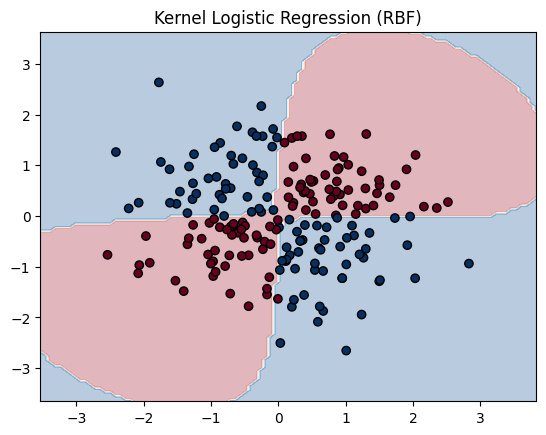

In [33]:
from utils import plot_boundary
from models import KernelLogisticRegression

# Ví dụ sử dụng trên dữ liệu XOR để thấy ranh giới phi tuyến
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)

# Khởi tạo Kernel LR với RBF Kernel (hàm Gaussian)
kernel_model = KernelLogisticRegression(
    kernel='rbf', 
    gamma=0.5, 
    lam=1e-4, 
    learning_rate=0.05, 
    max_iter=2000
)

models['Kernel Logistic Regression (RBF)'] = kernel_model

# Huấn luyện
kernel_model.fit(X_xor, y_xor)

# Dự đoán và kiểm tra độ chính xác
y_pred_xor = kernel_model.predict(X_xor)
print(f"Kernel LR Accuracy (XOR): {np.mean(y_pred_xor == y_xor):.4f}")

# Đoạn code vẽ Decision Boundary (được imported từ utils)
plot_boundary(kernel_model, X_xor, y_xor, "Kernel Logistic Regression (RBF)")


# 4. Đánh giá mô hình <a id='4'></a>

## 4.1 Đồ thị hàm mất mát theo số vòng lặp

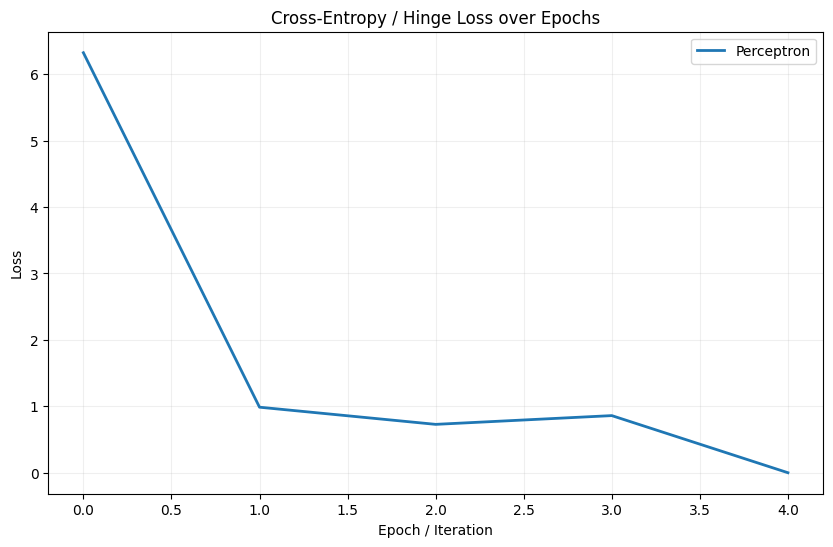

In [34]:
from eval import plot_loss_curves

# Plotting the loss histories for models that kept it
models_to_plot = {}
if 'model' in globals() and hasattr(model, 'loss_history_'):
    models_to_plot["Logistic Regression"] = model
if 'perceptron_clf' in globals() and hasattr(perceptron_clf, 'loss_history_'):
    models_to_plot["Perceptron"] = perceptron_clf

if models_to_plot:
    plot_loss_curves(models_to_plot, title="Cross-Entropy / Hinge Loss over Epochs")


## 4.2 Vẽ đường ranh giới quyết định trong không gian 2D

Vẽ đường ranh giới quyết định (Decision Boundaries) cho tập nhị phân 2D:


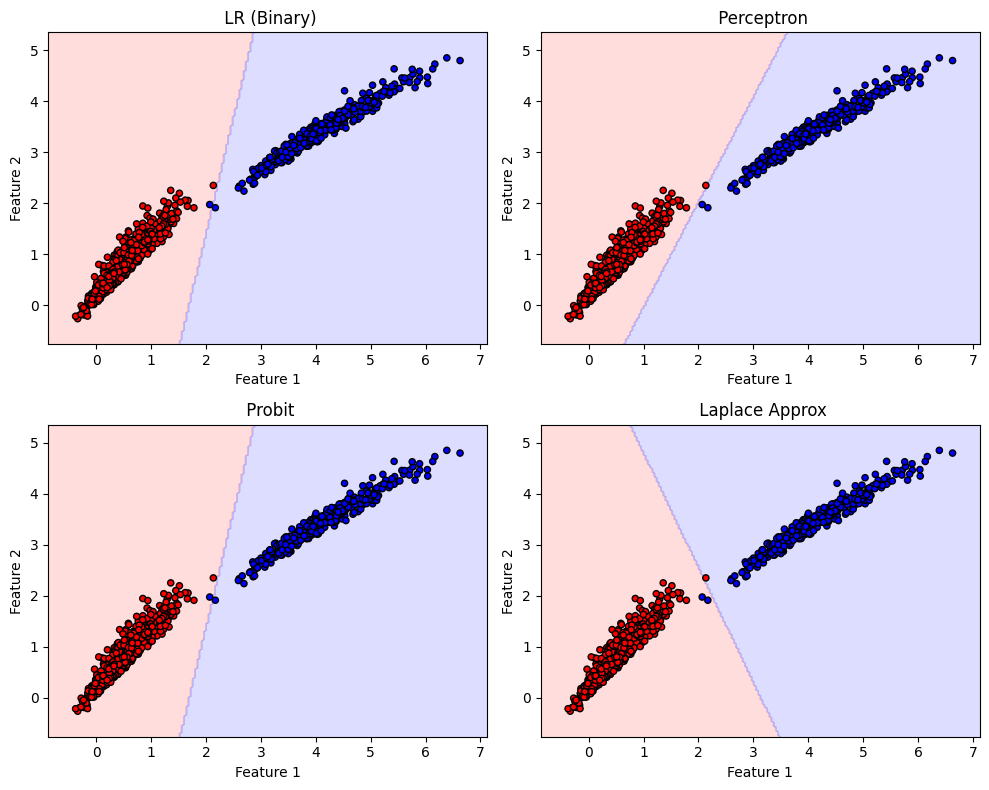

In [35]:
from utils import plot_2d_decision_boundary

# Collect binary models trained on 2D space (X_train_bin) earlier
binary_2d_models = {}
if 'logreg' in globals(): binary_2d_models['LR (Binary)'] = logreg
if 'perceptron_clf' in globals(): binary_2d_models['Perceptron'] = perceptron_clf
if 'probit_model' in globals(): binary_2d_models['Probit'] = probit_model
if 'blr' in globals(): binary_2d_models['Laplace Approx'] = blr

if binary_2d_models:
    print("Vẽ đường ranh giới quyết định (Decision Boundaries) cho tập nhị phân 2D:")
    plot_2d_decision_boundary(binary_2d_models, X_train_bin, y_train_bin)
else:
    print("Không tìm thấy mô hình nhị phân 2D nào được huấn luyện trước đó.")


## 4.3 So sánh tất cả các mô hình trong một bảng kết quả thống nhất

## 4.4 k-fold cross-validation (k=5) và báo cáo $\text{mean} \pm \text{std}$ cho mỗi chỉ số

In [36]:
from eval import kfold_cross_val_score

retrained_models = {
  "Softmax Regression": lambda: SR(learning_rate=LEARNING_RATE, eps=EPS, max_iter=MAX_ITER),
  "LDA": lambda: LDA(reg=REG),
  "QDA": lambda: QDA(reg=REG),
  "Gaussian Naive Bayes": lambda: GNB(reg=REG),
}

metric_order = ["accuracy", "precision", "recall", "f1-score"]
cv_rows = []

for model_name, builder in retrained_models.items():
  result = kfold_cross_val_score(
    model=builder(),
    X=X_train_scaled,
    y=y_train,
    k=5,
    average="weighted",
    random_state=SEED,
    shuffle=True,
    model_builder=builder,
  )

  row = {"Model": model_name}
  for metric in metric_order:
    row[metric] = result["summary"][metric]["mean_std"]
  cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index("Model")
print("5-fold cross-validation results (mean +- std):")
cv_df

Iteration 0: Loss 1.9459
Iteration 100: Loss 1.2213
Iteration 200: Loss 0.9942
Iteration 300: Loss 0.8742
Iteration 400: Loss 0.7942
Iteration 500: Loss 0.7347
Iteration 600: Loss 0.6876
Iteration 700: Loss 0.6490
Iteration 800: Loss 0.6165
Iteration 900: Loss 0.5888
Iteration 1000: Loss 0.5647
Iteration 1100: Loss 0.5437
Iteration 1200: Loss 0.5250
Iteration 1300: Loss 0.5084
Iteration 1400: Loss 0.4935
Iteration 1500: Loss 0.4801
Iteration 1600: Loss 0.4679
Iteration 1700: Loss 0.4568
Iteration 1800: Loss 0.4466
Iteration 1900: Loss 0.4373
Iteration 2000: Loss 0.4286
Iteration 2100: Loss 0.4206
Iteration 2200: Loss 0.4132
Iteration 2300: Loss 0.4063
Iteration 2400: Loss 0.3999
Iteration 2500: Loss 0.3939
Iteration 2600: Loss 0.3883
Iteration 2700: Loss 0.3830
Iteration 2800: Loss 0.3780
Iteration 2900: Loss 0.3733
Iteration 3000: Loss 0.3688
Iteration 3100: Loss 0.3646
Iteration 3200: Loss 0.3606
Iteration 3300: Loss 0.3569
Iteration 3400: Loss 0.3533
Iteration 3500: Loss 0.3499
Iter

,accuracy,precision,recall,f1-score
Model,,,,
Softmax Regression,0.9194 +- 0.0026,0.9198 +- 0.0028,0.9194 +- 0.0026,0.9193 +- 0.0027
LDA,0.9026 +- 0.0051,0.9130 +- 0.0044,0.9026 +- 0.0051,0.9043 +- 0.0050
QDA,0.9092 +- 0.0061,0.9139 +- 0.0060,0.9092 +- 0.0061,0.9098 +- 0.0060
Gaussian Naive Bayes,0.8959 +- 0.0037,0.8971 +- 0.0040,0.8959 +- 0.0037,0.8959 +- 0.0037


## 4.5 Vẽ **Precision-Recall curve** và so sánh Average Precision (AP) giữa các mô hình

Skip Logistic Regression (Binary): matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 17)
Skip Bayesian Logistic Regression (Laplace): matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 17)
Skip Probit Regression: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 17)
Skip Kernel Logistic Regression (RBF): shapes (5,16) and (2,200) not aligned: 16 (dim 1) != 2 (dim 0)


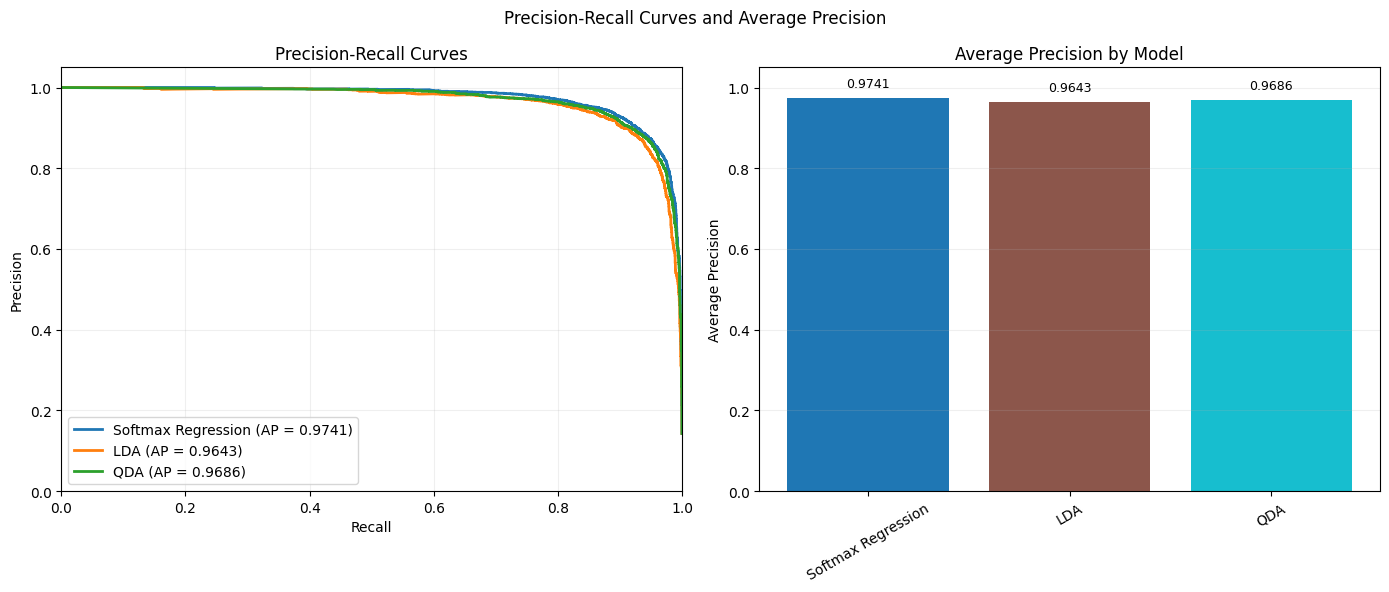


Average Precision by model:
Softmax Regression: 0.9741
QDA: 0.9686
LDA: 0.9643


In [37]:
from eval import compare_average_precision

models_for_pr = {}
for name, model in models.items():
  if not hasattr(model, "predict_proba"):
    print(f"Skip {name}: no predict_proba")
    continue

  try:
    _ = model.predict_proba(X_test_scaled[:5])
    models_for_pr[name] = model
  except Exception as e:
    print(f"Skip {name}: {e}")

if len(models_for_pr) == 0:
  raise ValueError("No valid models found for precision-recall plotting.")

ap_scores = compare_average_precision(
  models=models_for_pr,
  X=X_test_scaled,
  y_true=y_test,
  title="Precision-Recall Curves and Average Precision"
)

print("\nAverage Precision by model:")
for name, score in sorted(ap_scores.items(), key=lambda x: x[1], reverse=True):
  print(f"{name}: {score:.4f}")

## 4.6 McNemar's test

In [38]:
pairs = [
  ('GNB', 'LDA', gnb_preds, lda_preds),
  ('GNB', 'QDA', gnb_preds, qda_preds),
  ('LDA', 'QDA', lda_preds, qda_preds),
  ('LR', 'BLR', logreg_preds, blr_preds),
]

for pair in pairs:
  name1, name2, preds1, preds2 = pair
  p_value = mcnemar_paired(preds1, preds2, y_test)
  print(f'McNemar test between {name1} and {name2}: p-value = {p_value:.4f}')
  if p_value < ALPHA:
    print(f'--> The difference between {name1} and {name2} is statistically significant at alpha={ALPHA}')
  else:
    print(f'--> No statistically significant difference between {name1} and {name2} at alpha={ALPHA}')

TypeError: unsupported format string passed to dict.__format__

## 4.7 Phân tích Calibration của xác suất đầu ra bằng reliability diagram.

In [ ]:
# Models already fitted earlier in the notebook
models_for_calibration = {
    'LDA': lda,
    'QDA': qda,
    'GNB': gnb,
    'BLR': blr,
    # 'LR': lr,   # uncomment if this model has predict_proba(...)
}

n_bins = 10
fig, axes = plt.subplots(1, len(models_for_calibration), figsize=(5 * len(models_for_calibration), 4), sharey=True)

if len(models_for_calibration) == 1:
  axes = [axes]

calibration_summary = []

for ax, (model_name, model) in zip(axes, models_for_calibration.items()):
  y_prob = model.predict_proba(X_test_scaled)

  bin_centers, counts, conf_mean, acc_mean, ece = reliability_diagram_multiclass(
    y_true=y_test,
    probs=y_prob,
    class_labels=model.classes_,
    n_bins=n_bins,
  )

  valid = ~np.isnan(conf_mean) & ~np.isnan(acc_mean)

  ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfect calibration')
  ax.plot(conf_mean[valid], acc_mean[valid], marker='o', linewidth=2, label='Observed')
  ax.bar(
    bin_centers,
    np.nan_to_num(acc_mean, nan=0.0),
    width=1.0 / n_bins,
    alpha=0.25,
    edgecolor='black',
  )

  ax.set_ylim(0, 1)

  calibration_summary.append({
    'model': model_name,
    'ece': ece,
    'avg_confidence': float(np.nanmean(conf_mean)),
    'avg_accuracy': float(np.nanmean(acc_mean)),
  })

axes[0].set_ylabel('Empirical accuracy')
axes[0].legend(loc='lower right')
plt.suptitle('Calibration analysis with reliability diagrams', y=1.02)
plt.tight_layout()
plt.show()

calibration_summary = sorted(calibration_summary, key=lambda x: x['ece'])
print('Calibration summary (lower ECE is better):')
for row in calibration_summary:
  print(
    f"{row['model']}: "
    f"ECE={row['ece']:.4f}, "
    f"avg_confidence={row['avg_confidence']:.4f}, "
    f"avg_accuracy={row['avg_accuracy']:.4f}"
  )

## 4.8 Vẽ ROC Curve và AUC

In [ ]:
from eval import plot_roc_curve

if 'logreg' in globals():
    try:
        plot_roc_curve(logreg, X_test_bin, y_test_bin, title="ROC Curve - Logistic Regression Binary")
    except Exception as e:
        print("Could not plot ROC for logreg:", e)
        
if 'perceptron_clf' in globals():
    try:
        plot_roc_curve(perceptron_clf, X_test_bin, y_test_bin, title="ROC Curve - Perceptron Binary")
    except Exception as e:
        print("Could not plot ROC for perceptron:", e)
